**Predicting Term Deposit Subscription Using Direct Marketing Campaign Data**

Dataset used : https://archive.ics.uci.edu/dataset/222/bank+marketing

Use 'bank-full.csv' from the zip file

## **Importing Libraries and Loading the Dataset**

In [ ]:
# General Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch Libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

# Scikit-learn Libraries
from sklearn.preprocessing import StandardScaler, Binarizer, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif, chi2, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    classification_report
)
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, learning_curve

# Imbalanced Data Handling
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN

# Statistical Tests
from scipy.stats import chi2_contingency




In [ ]:
# Load the dataset
file_path = 'bank-full.csv'
data = pd.read_csv(file_path, sep=';')

## train test split with stratification (train and validation 85%, hidden test 15%)
data_train, data_test = train_test_split(data, test_size=.15, stratify=data['y'], random_state=42)
data_train.to_csv('train.csv', index=False, sep=';')
data_test.to_csv('test.csv', index=False, sep=';')


In [ ]:
print(data)

       age           job   marital  education default  balance housing loan  \
0       58    management   married   tertiary      no     2143     yes   no   
1       44    technician    single  secondary      no       29     yes   no   
2       33  entrepreneur   married  secondary      no        2     yes  yes   
3       47   blue-collar   married    unknown      no     1506     yes   no   
4       33       unknown    single    unknown      no        1      no   no   
...    ...           ...       ...        ...     ...      ...     ...  ...   
45206   51    technician   married   tertiary      no      825      no   no   
45207   71       retired  divorced    primary      no     1729      no   no   
45208   72       retired   married  secondary      no     5715      no   no   
45209   57   blue-collar   married  secondary      no      668      no   no   
45210   37  entrepreneur   married  secondary      no     2971      no   no   

         contact  day month  duration  campaign  pd

In [ ]:
print(f"Shape of train and validation dataset: {data_train.shape}")

Shape of train and validation dataset: (38429, 17)


In [ ]:
print(f"Shape of hidden dataset: {data_test.shape}")

Shape of hidden dataset: (6782, 17)


In [ ]:
# Load the dataset, only training set
file_path = 'train.csv'
data = pd.read_csv(file_path, sep=';')

# Display dataset information
print("Dataset Overview")
print("Shape of the dataset:", data.shape)
data.info()

# Display the first few rows of the dataset
print("\nFirst five rows of the dataset:")
print(data.head())

# Check for missing values
print("\nMissing values in the dataset:")
print(data.isnull().sum())

Dataset Overview
Shape of the dataset: (38429, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38429 entries, 0 to 38428
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        38429 non-null  int64 
 1   job        38429 non-null  object
 2   marital    38429 non-null  object
 3   education  38429 non-null  object
 4   default    38429 non-null  object
 5   balance    38429 non-null  int64 
 6   housing    38429 non-null  object
 7   loan       38429 non-null  object
 8   contact    38429 non-null  object
 9   day        38429 non-null  int64 
 10  month      38429 non-null  object
 11  duration   38429 non-null  int64 
 12  campaign   38429 non-null  int64 
 13  pdays      38429 non-null  int64 
 14  previous   38429 non-null  int64 
 15  poutcome   38429 non-null  object
 16  y          38429 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.0+ MB

First five rows of the dataset:
   age         

## **Data Exploration and Summary Statistics**


Summary statistics for numerical features:
                age        balance           day      duration      campaign  \
count  38429.000000   38429.000000  38429.000000  38429.000000  38429.000000   
mean      40.904525    1362.957012     15.798928    258.526243      2.762133   
std       10.622555    3047.062753      8.323266    258.804866      3.101618   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     450.000000     16.000000    180.000000      2.000000   
75%       48.000000    1430.000000     21.000000    318.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  38429.000000  38429.000000  
mean      40.169872      0.582607  
std      100.183378      2.380893  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000

<ipython-input-7-bc93d64f4578>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='y', data=data, palette='viridis')


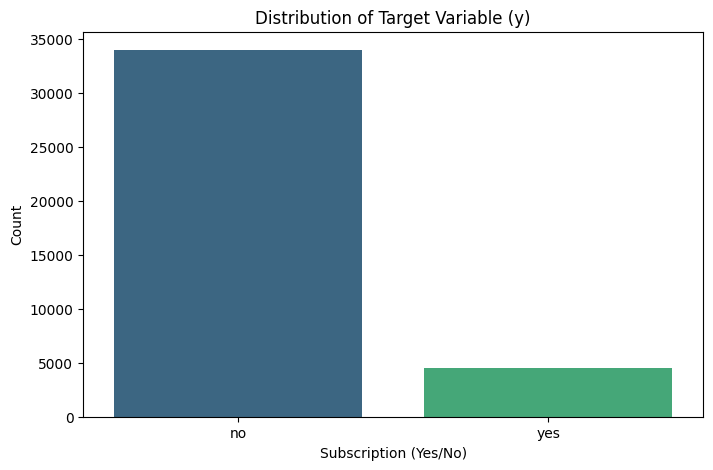

In [ ]:
# Summary statistics for numerical features
print("\nSummary statistics for numerical features:")
print(data.describe())

# Summary statistics for categorical features
print("\nSummary statistics for categorical features:")
print(data.describe(include=['object']))

# Distribution of the target variable
print("\nDistribution of the target variable (y):")
print(data['y'].value_counts(normalize=True))

# Visualize the target variable
plt.figure(figsize=(8, 5))
sns.countplot(x='y', data=data, palette='viridis')
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Subscription (Yes/No)')
plt.ylabel('Count')
plt.show()


## **Numerical Features Analysis**


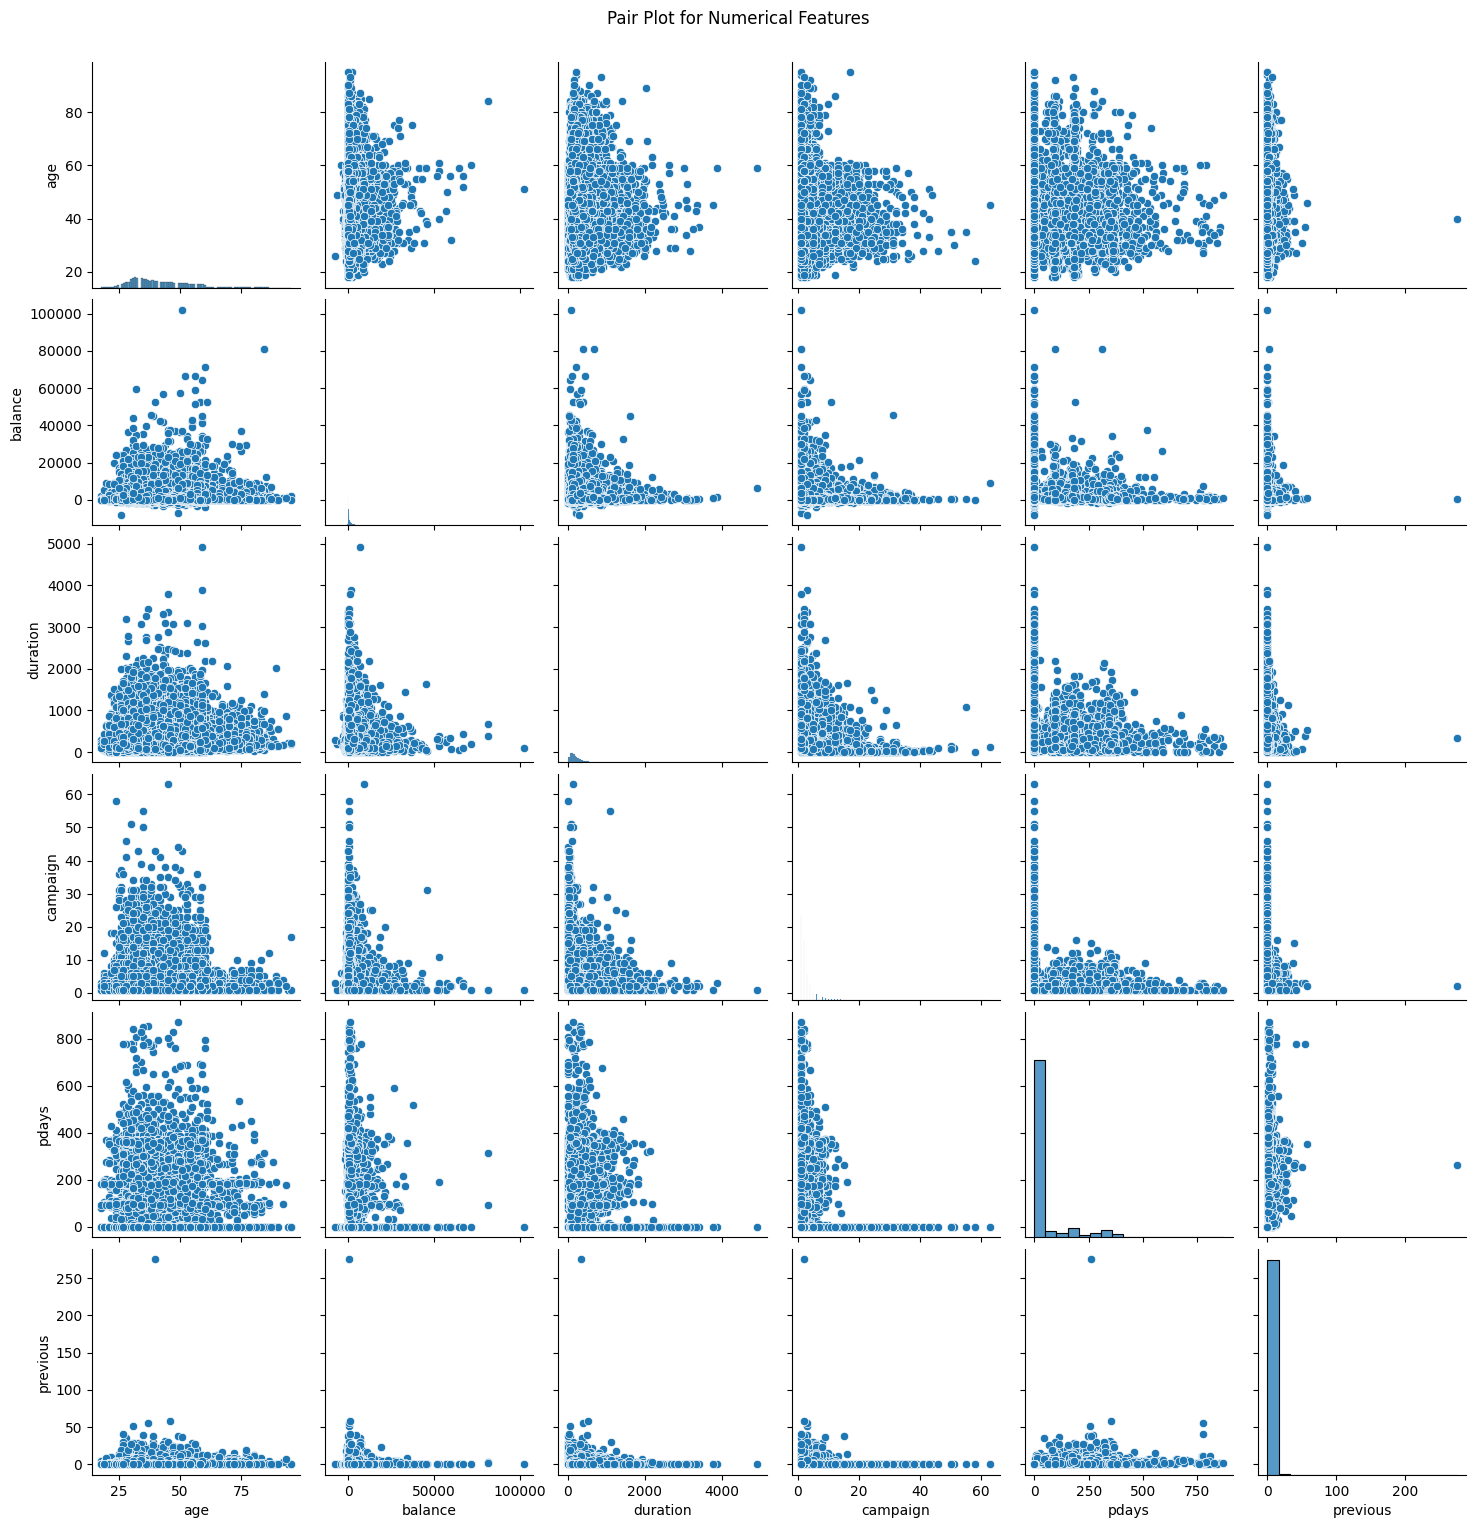

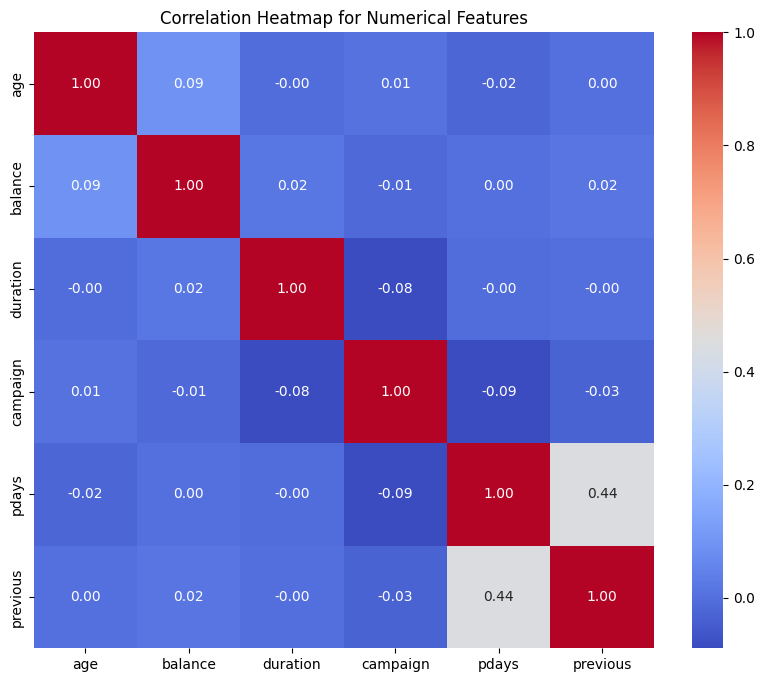

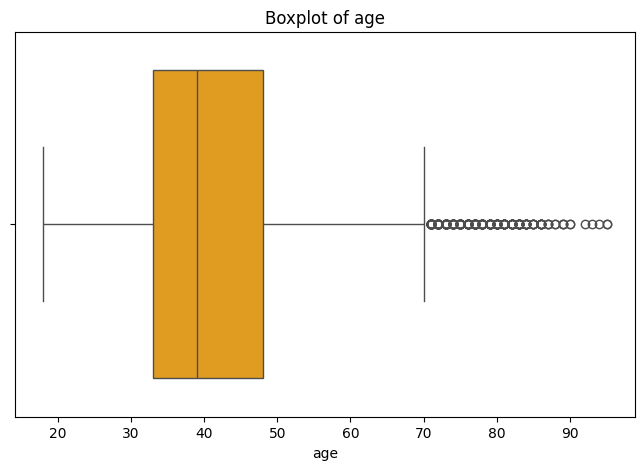

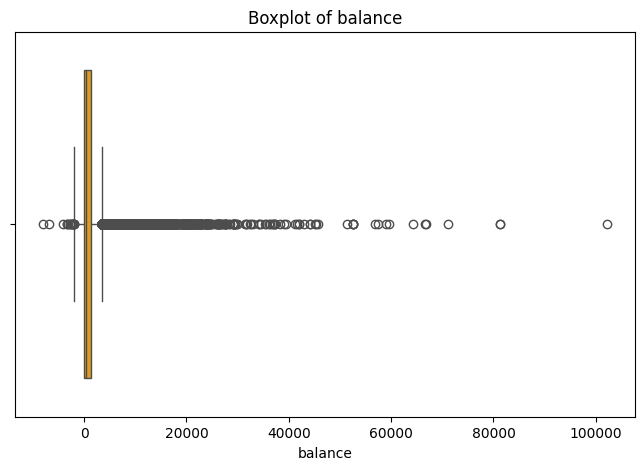

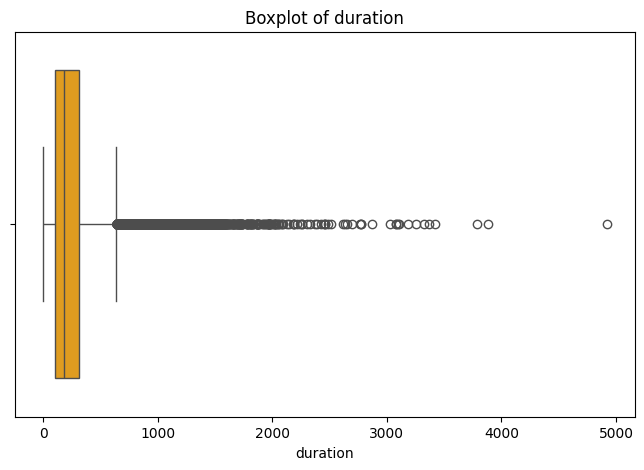

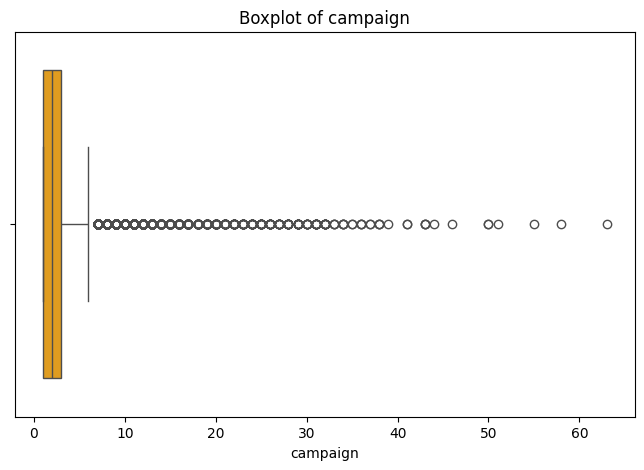

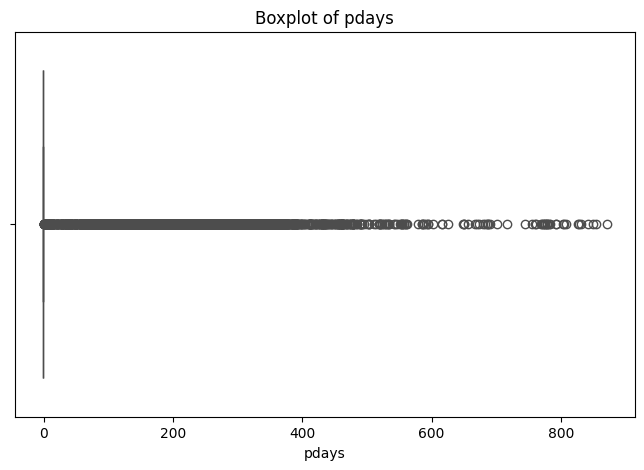

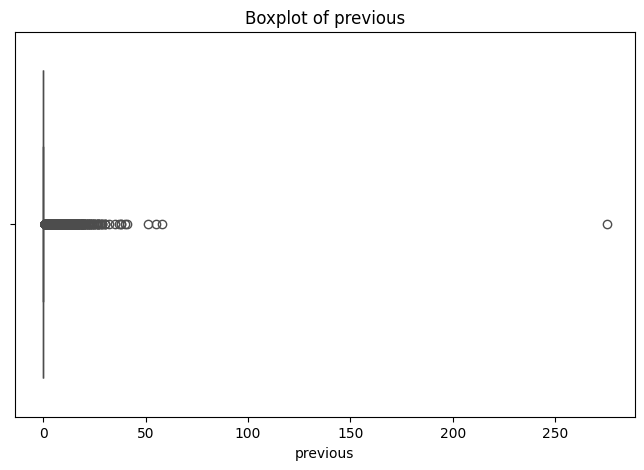

In [ ]:
# Numerical features
numerical_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

# Pair plot for numerical features
sns.pairplot(data[numerical_features])
plt.suptitle("Pair Plot for Numerical Features", y=1.02)
plt.show()

# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(data[numerical_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap for Numerical Features')
plt.show()

# Boxplots for outlier detection
for feature in numerical_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=data[feature], color='orange')
    plt.title(f'Boxplot of {feature}')
    plt.xlabel(feature)
    plt.show()


## **Categorical Features Analysis**

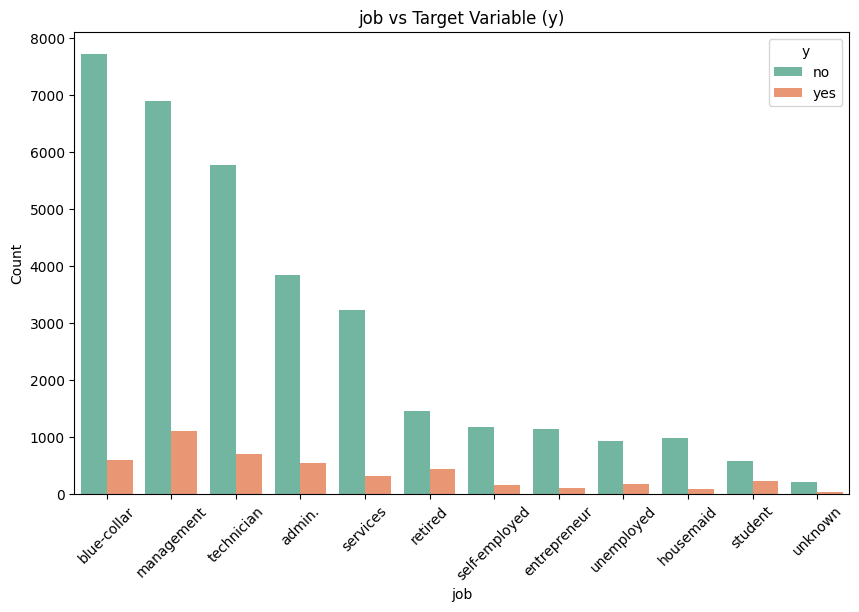

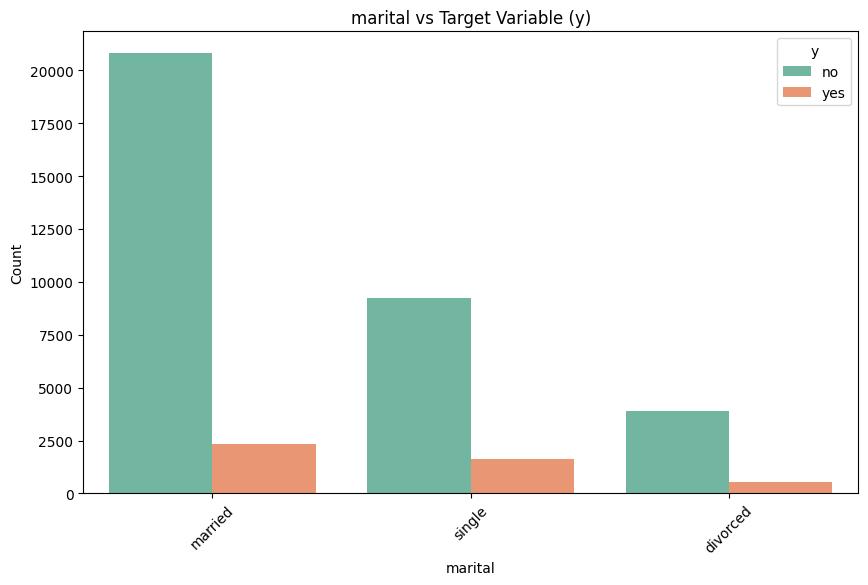

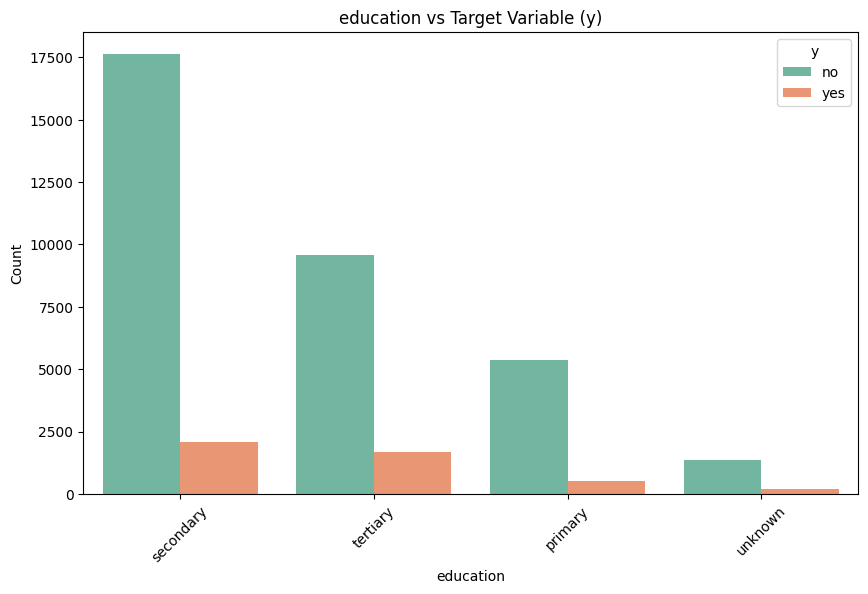

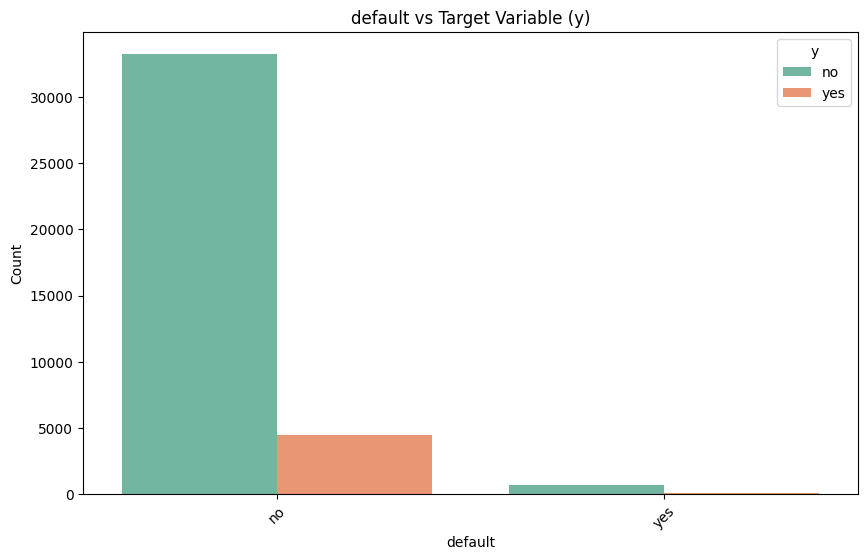

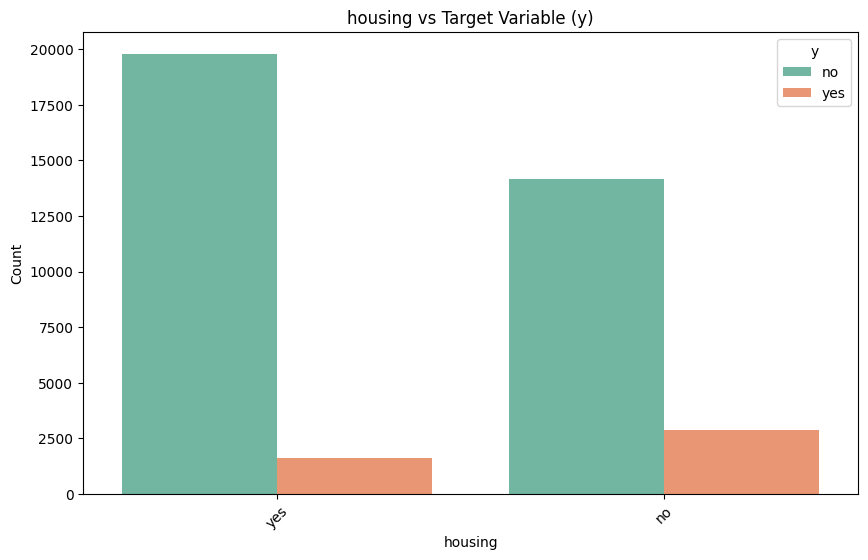

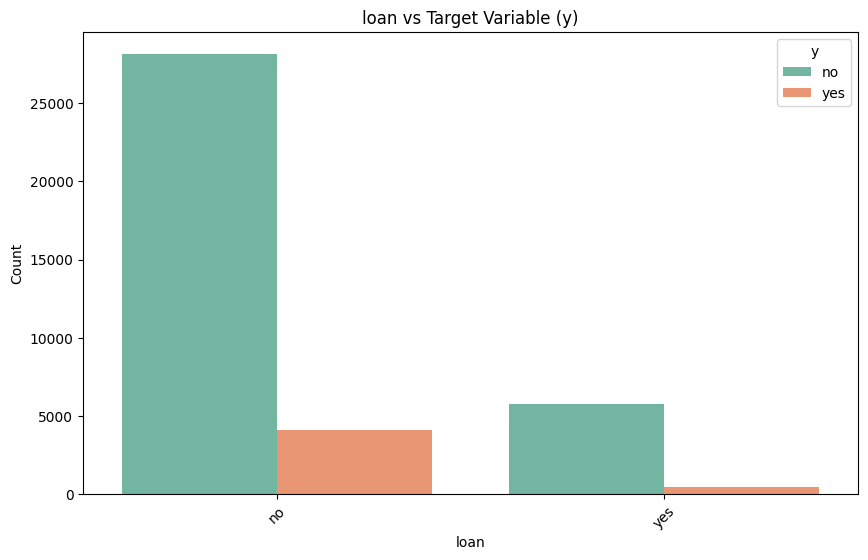

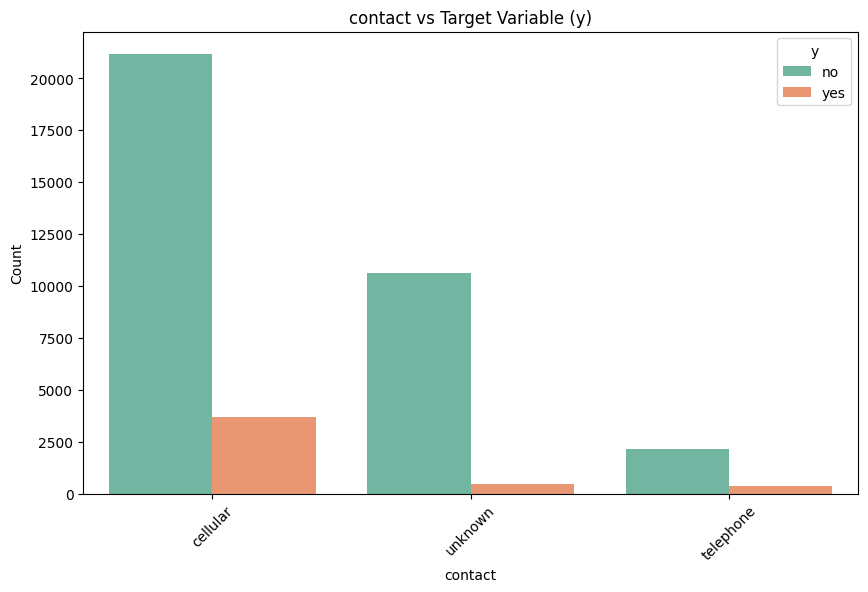

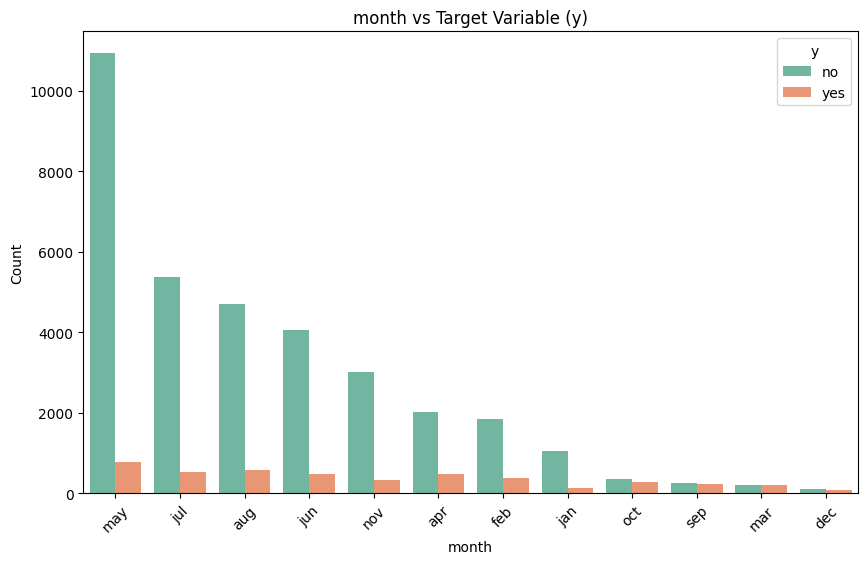

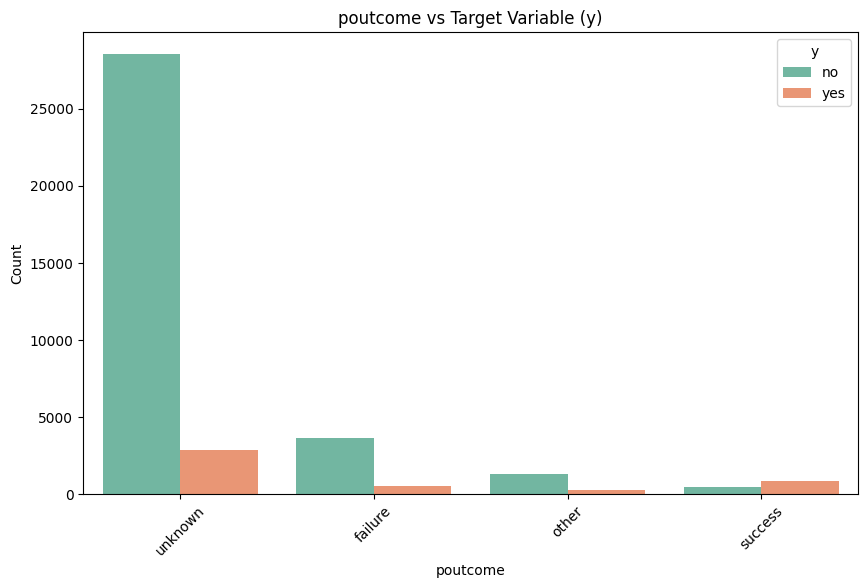

In [ ]:
# Categorical features
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

# Bar plots for categorical features vs target variable
for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=feature, hue='y', data=data, palette='Set2', order=data[feature].value_counts().index)
    plt.title(f'{feature} vs Target Variable (y)')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()


## **Feature Engineering**

In [ ]:
# Feature Engineering
# Binary flags for thresholds
data['long_campaign_contact'] = (data['campaign'] > 5).astype(int)
data['recent_contact'] = (data['pdays'] < 10).astype(int)

# Interaction terms
data['duration_campaign_interaction'] = data['duration'] * data['campaign']
data['contact_poutcome_interaction'] = data['contact'] + '_' + data['poutcome']
data['month_campaign_interaction'] = data['month'] + '_campaign_' + data['campaign'].astype(str)

# Group rare categories in 'job'
data['job_grouped'] = data['job'].replace(
    data['job'].value_counts()[data['job'].value_counts() < 500].index, 'Other'
)

# Verify the newly created features
print(data[['campaign', 'long_campaign_contact', 'pdays', 'recent_contact',
            'duration_campaign_interaction', 'job_grouped']].head())


   campaign  long_campaign_contact  pdays  recent_contact  \
0         1                      0    213               0   
1         1                      0     -1               1   
2         1                      0     -1               1   
3         7                      1     -1               1   
4         4                      0     -1               1   

   duration_campaign_interaction  job_grouped  
0                            232       admin.  
1                            259   technician  
2                            613  blue-collar  
3                            301     services  
4                            116   technician  


## **Outlier Handling**

In [ ]:
# Function to cap outliers
def cap_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    data[column] = data[column].clip(lower=lower_bound, upper=upper_bound)
    return data

# Apply outlier capping to numerical features
for feature in ['balance', 'duration']:
    data = cap_outliers(data, feature)

# Verify changes
print(data[['balance', 'duration']].describe())


            balance      duration
count  38429.000000  38429.000000
mean     935.186396    234.782885
std     1178.012742    176.286761
min    -1965.000000      0.000000
25%       72.000000    103.000000
50%      450.000000    180.000000
75%     1430.000000    318.000000
max     3467.000000    640.500000


## **Encoding Categorical Variables and Feature Selection**

In [ ]:


# Encode categorical features
categorical_features = ['job', 'marital', 'education', 'default', 'housing',
                        'loan', 'contact', 'month', 'poutcome']
encoder = OneHotEncoder(drop='first', sparse_output=False)  # Updated argument
X_cat = encoder.fit_transform(data[categorical_features])

# Verify the encoded data
print(X_cat[:5])

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0.
  0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
  0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
  0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0.
  0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


In [ ]:



# Numerical features
numerical_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']

# SelectKBest for numerical features
selector_num = SelectKBest(f_classif, k=3)
X_num_selected = selector_num.fit_transform(data[numerical_features], data['y'])
selected_numerical_features = [numerical_features[i] for i in selector_num.get_support(indices=True)]
print("Selected Numerical Features:", selected_numerical_features)

# SelectKBest for categorical features
selector_cat = SelectKBest(chi2, k=5)
X_cat_selected = selector_cat.fit_transform(X_cat, data['y'])
selected_categorical_features = [encoder.get_feature_names_out()[i] for i in selector_cat.get_support(indices=True)]
print("Selected Categorical Features:", selected_categorical_features)

Selected Numerical Features: ['balance', 'duration', 'pdays']
Selected Categorical Features: ['contact_unknown', 'month_mar', 'month_oct', 'month_sep', 'poutcome_success']


In [ ]:


# Prepare dataset for Random Forest
X = pd.concat([pd.DataFrame(X_cat, columns=encoder.get_feature_names_out()),
               data[numerical_features]], axis=1)
y = data['y']

# Train Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# Extract feature importance
feature_names = list(encoder.get_feature_names_out()) + numerical_features
feature_importances = pd.DataFrame({'Feature': feature_names, 'Importance': rf.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)
print("Top Features by Importance:")
print(feature_importances.head(10))


Top Features by Importance:
                Feature  Importance
37             duration    0.263975
35                  age    0.121327
36              balance    0.120725
33     poutcome_success    0.056206
38             campaign    0.049890
39                pdays    0.047325
17          housing_yes    0.024117
40             previous    0.023104
13  education_secondary    0.015904
20      contact_unknown    0.014385


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Logistic Regression for RFE
model = LogisticRegression(max_iter=500, random_state=42)
rfe = RFE(model, n_features_to_select=10)
X_rfe = rfe.fit_transform(X, y)

# Extract selected feature names
selected_features = [feature_names[i] for i in range(len(feature_names)) if rfe.support_[i]]
print("Selected Features via RFE:")
print(selected_features)


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Selected Features via RFE:
['housing_yes', 'contact_unknown', 'month_aug', 'month_dec', 'month_jan', 'month_jul', 'month_mar', 'month_oct', 'month_sep', 'poutcome_success']


In [ ]:
# Combine one-hot encoded features with engineered features
encoded_feature_names = encoder.get_feature_names_out(categorical_features)

# Convert one-hot encoded features to a DataFrame
X_encoded_df = pd.DataFrame(X_cat, columns=encoded_feature_names, index=data.index)

# Add engineered features to the encoded dataset
engineered_features = ['long_campaign_contact', 'recent_contact', 'duration_campaign_interaction']
X_final = pd.concat([X_encoded_df, data[engineered_features]], axis=1)

# Define the target variable
y_final = data['y']

print("Final dataset ready for modeling:")
print(X_final.head())

Final dataset ready for modeling:
   job_blue-collar  job_entrepreneur  job_housemaid  job_management  \
0              0.0               0.0            0.0             0.0   
1              0.0               0.0            0.0             0.0   
2              1.0               0.0            0.0             0.0   
3              0.0               0.0            0.0             0.0   
4              0.0               0.0            0.0             0.0   

   job_retired  job_self-employed  job_services  job_student  job_technician  \
0          0.0                0.0           0.0          0.0             0.0   
1          0.0                0.0           0.0          0.0             1.0   
2          0.0                0.0           0.0          0.0             0.0   
3          0.0                0.0           1.0          0.0             0.0   
4          0.0                0.0           0.0          0.0             1.0   

   job_unemployed  ...  month_may  month_nov  month_oct  m

In [ ]:
X_final

,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,...,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,long_campaign_contact,recent_contact,duration_campaign_interaction
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,232
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,259
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,613
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1,1,301
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38424,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,2430
38425,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,98
38426,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,1,227
38427,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0,1,649


In [ ]:
# Display the columns of the final dataset
print("Columns in the final dataset:")
print(X_final.columns.tolist())


Columns in the final dataset:
['job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'long_campaign_contact', 'recent_contact', 'duration_campaign_interaction']


In [ ]:
# Convert 'y' to numeric
data['y'] = data['y'].map({'yes': 1, 'no': 0})

# Recalculating correlation
correlation_age = data[['age', 'y']].corr()
print("Correlation between age and the target variable (y):")
print(correlation_age)


Correlation between age and the target variable (y):
          age         y
age  1.000000  0.025862
y    0.025862  1.000000


<ipython-input-20-493f78e68f66>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='y', y='age', data=data, palette='Set2')


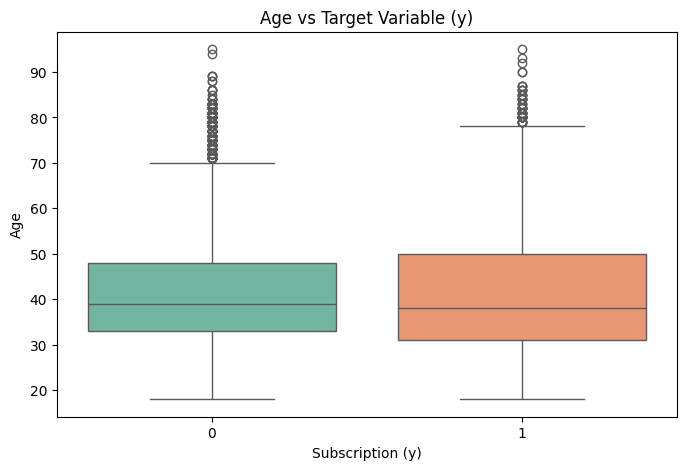

In [ ]:
# Boxplot of age vs target variable
plt.figure(figsize=(8, 5))
sns.boxplot(x='y', y='age', data=data, palette='Set2')
plt.title('Age vs Target Variable (y)')
plt.xlabel('Subscription (y)')
plt.ylabel('Age')
plt.show()


   age    age_group
0   44        Adult
1   36        Adult
2   51  Middle-Aged
3   33        Adult
4   42        Adult

Subscription rates by age group:
age_group
Youth          0.241529
Adult          0.107659
Middle-Aged    0.107442
Senior         0.431925
Name: y, dtype: float64


<ipython-input-21-30de19247c56>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_subscription = data.groupby('age_group')['y'].mean()


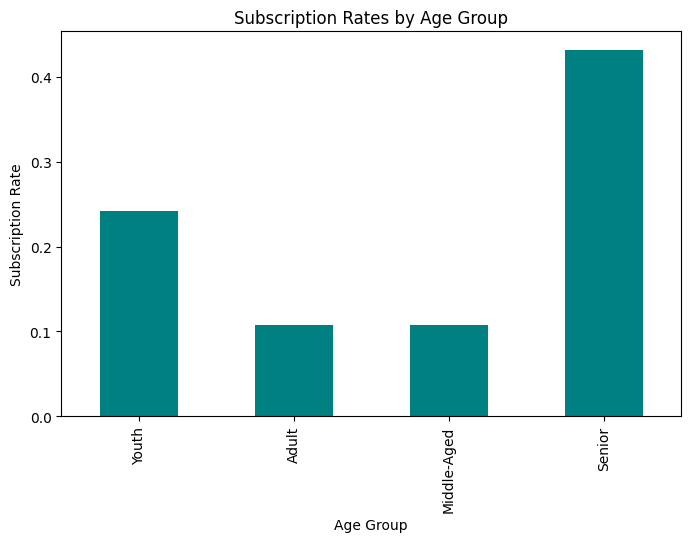

In [ ]:
# Group age into categories
data['age_group'] = pd.cut(data['age'], bins=[0, 25, 45, 65, 100], labels=['Youth', 'Adult', 'Middle-Aged', 'Senior'])
print(data[['age', 'age_group']].head())

# Analyze subscription rates by age group
age_group_subscription = data.groupby('age_group')['y'].mean()
print("\nSubscription rates by age group:")
print(age_group_subscription)

# Bar plot for age group subscription rates
age_group_subscription.plot(kind='bar', figsize=(8, 5), color='teal')
plt.title('Subscription Rates by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Subscription Rate')
plt.show()


In [ ]:
original_columns = data.columns.tolist()
print("Original Dataset Columns:", original_columns)


Original Dataset Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y', 'long_campaign_contact', 'recent_contact', 'duration_campaign_interaction', 'contact_poutcome_interaction', 'month_campaign_interaction', 'job_grouped', 'age_group']


In [ ]:
final_columns = X_final.columns.tolist()
print("Final Dataset Columns:", final_columns)


Final Dataset Columns: ['job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'long_campaign_contact', 'recent_contact', 'duration_campaign_interaction']


In [ ]:
omitted_features = set(original_columns) - set(final_columns)
print("Omitted Features:", omitted_features)


Omitted Features: {'duration', 'loan', 'contact', 'day', 'month_campaign_interaction', 'pdays', 'housing', 'marital', 'education', 'job_grouped', 'poutcome', 'contact_poutcome_interaction', 'age_group', 'campaign', 'default', 'balance', 'y', 'month', 'previous', 'age', 'job'}


In [ ]:
# Re-run correlation analysis for specific omitted features
features_to_check = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
correlation = data[features_to_check + ['y']].corr()

# Display the correlation matrix
print("Correlation of omitted features with the target variable (y):")
print(correlation['y'])


Correlation of omitted features with the target variable (y):
age         0.025862
balance     0.092350
duration    0.389657
campaign   -0.072999
pdays       0.101426
previous    0.090643
y           1.000000
Name: y, dtype: float64


In [ ]:

# Define the omitted features and target
X_omitted = data[features_to_check]
y = data['y']

# Train a Random Forest model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_omitted, y)

# Feature importance
feature_importances = pd.DataFrame({
    'Feature': features_to_check,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature importance for omitted features:")
print(feature_importances)



Feature importance for omitted features:
    Feature  Importance
2  duration    0.358576
1   balance    0.257409
0       age    0.190957
4     pdays    0.106599
3  campaign    0.052534
5  previous    0.033924



Subscription rates by age group:
age_group
Youth          0.241529
Adult          0.107659
Middle-Aged    0.107442
Senior         0.431925
Name: y, dtype: float64


<ipython-input-27-c02eb71d8b5e>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_subscription = data.groupby('age_group')['y'].mean()


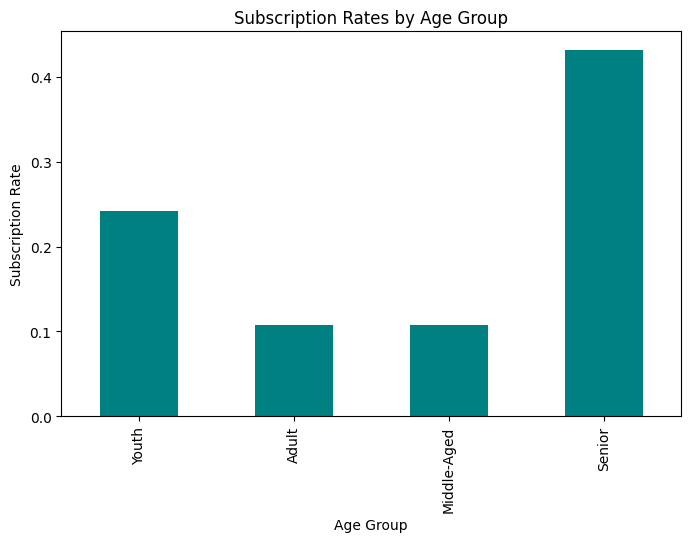

In [ ]:
# Group 'age' into categories for comparison
data['age_group'] = pd.cut(data['age'], bins=[0, 25, 45, 65, 100], labels=['Youth', 'Adult', 'Middle-Aged', 'Senior'])

# Compare subscription rates by age group
age_group_subscription = data.groupby('age_group')['y'].mean()
print("\nSubscription rates by age group:")
print(age_group_subscription)

# Plot subscription rates by age group
age_group_subscription.plot(kind='bar', figsize=(8, 5), color='teal')
plt.title('Subscription Rates by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Subscription Rate')
plt.show()


In [ ]:
# Step 1: Create age_group
data['age_group'] = pd.cut(data['age'], bins=[0, 25, 45, 65, 100], labels=['Youth', 'Adult', 'Middle-Aged', 'Senior'])

# Step 2: Select relevant features
numerical_features = ['duration', 'balance', 'pdays']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
engineered_features = ['duration_campaign_interaction', 'long_campaign_contact', 'recent_contact', 'age_group']

# Step 3: One-hot encode categorical features
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_cat = encoder.fit_transform(data[categorical_features + ['age_group']])
encoded_feature_names = encoder.get_feature_names_out(categorical_features + ['age_group'])

# Step 4: Combine numerical, encoded, and engineered features
X_encoded_df = pd.DataFrame(X_cat, columns=encoded_feature_names, index=data.index)
X_final = pd.concat([X_encoded_df, data[numerical_features + engineered_features]], axis=1)

# Step 5: Define the target variable
y_final = data['y']

# Verify the final dataset
print("Final dataset ready for modeling:")
print(X_final.head())
print("Final feature names:", X_final.columns.tolist())


Final dataset ready for modeling:
   job_blue-collar  job_entrepreneur  job_housemaid  job_management  \
0              0.0               0.0            0.0             0.0   
1              0.0               0.0            0.0             0.0   
2              1.0               0.0            0.0             0.0   
3              0.0               0.0            0.0             0.0   
4              0.0               0.0            0.0             0.0   

   job_retired  job_self-employed  job_services  job_student  job_technician  \
0          0.0                0.0           0.0          0.0             0.0   
1          0.0                0.0           0.0          0.0             1.0   
2          0.0                0.0           0.0          0.0             0.0   
3          0.0                0.0           1.0          0.0             0.0   
4          0.0                0.0           0.0          0.0             1.0   

   job_unemployed  ...  age_group_Middle-Aged  age_group_S

In [ ]:
X_final = X_final.drop(columns=['age_group'])


In [ ]:

if 'campaign' not in X_final.columns:
    X_final['campaign'] = data['campaign']

# Check correlation of 'campaign' with other features
correlations = X_final[['campaign', 'duration_campaign_interaction', 'duration']].corrwith(y_final)
print("Correlation of 'campaign' with interaction and target:")
print(correlations)



Correlation of 'campaign' with interaction and target:
campaign                        -0.072999
duration_campaign_interaction    0.207390
duration                         0.389657
dtype: float64


In [ ]:
# Drop 'campaign' from the final dataset
X_final = X_final.drop(columns=['campaign'])

# Verify updated dataset
print("Updated shape of the dataset:", X_final.shape)
print("Updated feature names:", X_final.columns.tolist())


Updated shape of the dataset: (38429, 44)
Updated feature names: ['job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'marital_married', 'marital_single', 'education_secondary', 'education_tertiary', 'education_unknown', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'age_group_Middle-Aged', 'age_group_Senior', 'age_group_Youth', 'duration', 'balance', 'pdays', 'duration_campaign_interaction', 'long_campaign_contact', 'recent_contact']


In [ ]:
y_final

,y
0,0
1,0
2,0
3,0
4,0
...,...
38424,1
38425,0
38426,0
38427,1


In [ ]:
# Check class distribution in y_final
print("Class distribution in y_final:")
print(pd.Series(y_final).value_counts(normalize=True))


Class distribution in y_final:
y
0    0.883005
1    0.116995
Name: proportion, dtype: float64


## **Splitting dataset into train and validation**

In [ ]:


# Split data into training and testing sets
X_train, X_valid, y_train, y_valid = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

# Check class distribution in training and testing sets
print("Class distribution in training set (before SMOTE):")
print(pd.Series(y_train).value_counts(normalize=True))

print("\nClass distribution in testing set:")
print(pd.Series(y_valid).value_counts(normalize=True))


Class distribution in training set (before SMOTE):
y
0    0.882998
1    0.117002
Name: proportion, dtype: float64

Class distribution in testing set:
y
0    0.883034
1    0.116966
Name: proportion, dtype: float64


## **Handling Imbalance in Class and Normalizing training data**

In [ ]:


# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check class distribution after SMOTE
print("\nClass distribution in training set (after SMOTE):")
print(pd.Series(y_train_resampled).value_counts(normalize=True))



Class distribution in training set (after SMOTE):
y
1    0.5
0    0.5
Name: proportion, dtype: float64


In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Apply normalization to training and testing sets
X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_valid_scaled = scaler.transform(X_valid)


## **Modelling**

### **Logistic Regression**

In [ ]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, tolerance=1e-4, max_iter=1000, lambda_=0.1):
        self.learning_rate = learning_rate
        self.tolerance = tolerance
        self.max_iter = max_iter
        self.lambda_ = lambda_
        self.weights = None
        self.bias = 0

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def cost_function(self, X, y):
        m = X.shape[0]
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        epsilon = 1e-10
        cost = -(1 / m) * np.sum(y * np.log(y_pred + epsilon) + (1 - y) * np.log(1 - y_pred + epsilon))
        reg_term = (self.lambda_ / (2 * m)) * np.sum(self.weights ** 2)
        return cost + reg_term

    def gradient(self, X, y):
        m = X.shape[0]
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)

        dw = (1 / m) * np.dot(X.T, (y_pred - y)) + (self.lambda_ / m) * self.weights
        db = (1 / m) * np.sum(y_pred - y)
        return dw, db

    def gradient_descent(self, X, y):
        for i in range(self.max_iter):
            dw, db = self.gradient(X, y)
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        return np.round(y_pred)

    def predict_proba(self, X):
        """
        Returns the predicted probabilities for both classes.
        """
        linear_model = np.dot(X, self.weights) + self.bias
        prob = self.sigmoid(linear_model)
        return np.vstack((1 - prob, prob)).T  # Return probabilities for both classes

    def fit(self, X, y):
        n_features = X.shape[1]
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.gradient_descent(X, y)

    def evaluate(self, X, y):
        y_pred = self.predict(X)
        precision = precision_score(y, y_pred)
        recall = recall_score(y, y_pred)
        f1 = f1_score(y, y_pred)
        accuracy = accuracy_score(y, y_pred)

        print(f"Accuracy: {accuracy}")
        print(f"Precision: {precision}")
        print(f"Recall: {recall}")
        print(f"F1 Score: {f1}")

        return precision, recall, f1, accuracy


In [ ]:

learning_rates = [0.001, 0.01, 0.1]
lambdas = [0.01, 0.1, 1]
max_iters = [500, 1000, 1500]

best_params = {}
best_f1 = 0

for lr in learning_rates:
    for lambda_ in lambdas:
        for max_iter in max_iters:
            print(f"Testing: lr={lr}, lambda_={lambda_}, max_iter={max_iter}")

            # Initialize and train the model
            logistic_model = LogisticRegression(learning_rate=lr, lambda_=lambda_, max_iter=max_iter)
            logistic_model.fit(X_train_resampled_scaled, y_train_resampled)

            # Evaluate on the test set
            precision, recall, f1, accuracy = logistic_model.evaluate(X_valid_scaled, y_valid)

            # Update best parameters if F1 score improves
            if f1 > best_f1:
                best_f1 = f1
                best_params = {"learning_rate": lr, "lambda_": lambda_, "max_iter": max_iter}

print(f"Best parameters: {best_params}")
print(f"Best F1 score: {best_f1}")



Testing: lr=0.001, lambda_=0.01, max_iter=500
Accuracy: 0.8032786885245902
Precision: 0.3430619559651818
Recall: 0.7452725250278087
F1 Score: 0.46984572230014027
Testing: lr=0.001, lambda_=0.01, max_iter=1000
Accuracy: 0.8108248763986469
Precision: 0.355543987506507
Recall: 0.7597330367074527
F1 Score: 0.48439716312056735
Testing: lr=0.001, lambda_=0.01, max_iter=1500
Accuracy: 0.8182409575852199
Precision: 0.36880927291886195
Recall: 0.778642936596218
F1 Score: 0.5005362888809438
Testing: lr=0.001, lambda_=0.1, max_iter=500
Accuracy: 0.8032786885245902
Precision: 0.3430619559651818
Recall: 0.7452725250278087
F1 Score: 0.46984572230014027
Testing: lr=0.001, lambda_=0.1, max_iter=1000
Accuracy: 0.8108248763986469
Precision: 0.355543987506507
Recall: 0.7597330367074527
F1 Score: 0.48439716312056735
Testing: lr=0.001, lambda_=0.1, max_iter=1500
Accuracy: 0.8182409575852199
Precision: 0.36880927291886195
Recall: 0.778642936596218
F1 Score: 0.5005362888809438
Testing: lr=0.001, lambda_=1, m

In [ ]:

# Retrain with best parameters
best_model_logistic = LogisticRegression(
    learning_rate=0.01,
    lambda_=0.01,
    max_iter=1500
)

# Train the model
best_model_logistic.fit(X_train_resampled_scaled, y_train_resampled)

# Evaluate performance
print("Final Training Performance:")
best_model_logistic.evaluate(X_train_resampled_scaled, y_train_resampled)

print("\nFinal Testing Performance:")
best_model_logistic.evaluate(X_valid_scaled, y_valid)

Final Training Performance:
Accuracy: 0.8531643704413173
Precision: 0.8468021993922732
Recall: 0.8623369925587564
F1 Score: 0.8544989961671838

Final Testing Performance:
Accuracy: 0.8367161072079105
Precision: 0.40251916757940853
Recall: 0.8175750834260289
F1 Score: 0.5394495412844037


(0.40251916757940853,
 0.8175750834260289,
 0.5394495412844037,
 0.8367161072079105)

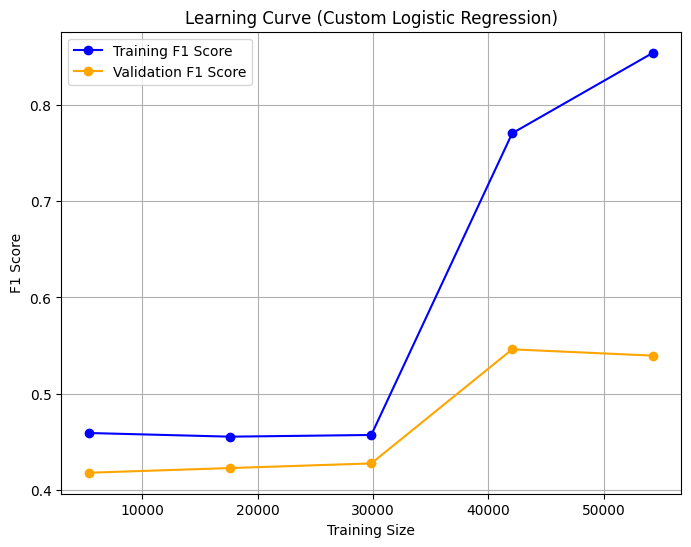

In [ ]:


# learning curve
def plot_learning_curve_custom(model, X_train, y_train, X_valid, y_valid, title):
    train_sizes = np.linspace(0.1, 1.0, 5)  # 10% to 100% of the training data
    train_scores = []
    valid_scores = []

    for size in train_sizes:

        subset_size = int(size * len(X_train))
        X_train_subset = X_train[:subset_size]
        y_train_subset = y_train[:subset_size]

        # Train the model on the subset
        model.fit(X_train_subset, y_train_subset)

        # Evaluate on the training subset
        y_train_pred = model.predict(X_train_subset)
        train_f1 = f1_score(y_train_subset, y_train_pred)
        train_scores.append(train_f1)

        # Evaluate on the validation set
        y_valid_pred = model.predict(X_valid)
        valid_f1 = f1_score(y_valid, y_valid_pred)
        valid_scores.append(valid_f1)

    # Plot the learning curve
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes * len(X_train), train_scores, 'o-', label="Training F1 Score", color="blue")
    plt.plot(train_sizes * len(X_train), valid_scores, 'o-', label="Validation F1 Score", color="orange")
    plt.xlabel("Training Size")
    plt.ylabel("F1 Score")
    plt.title(title)
    plt.legend(loc="best")
    plt.grid()
    plt.show()


best_model_logistic = LogisticRegression(
    learning_rate=0.01,
    lambda_=0.01,
    max_iter=1500
)

# Plot the learning curve
plot_learning_curve_custom(
    best_model_logistic,
    X_train_resampled_scaled,
    y_train_resampled,
    X_valid_scaled,
    y_valid,
    "Learning Curve (Custom Logistic Regression)"
)


ROC-AUC Score: 0.9046597130908349
Precision-Recall AUC: 0.53


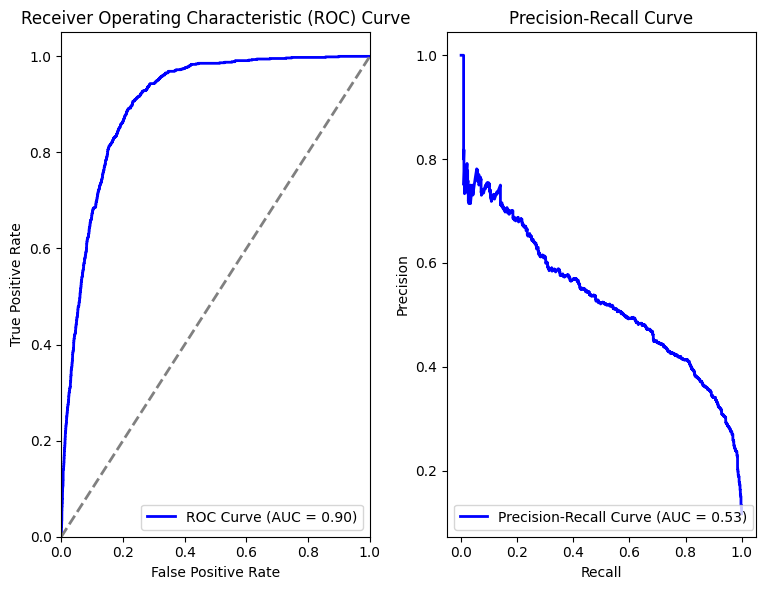

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      6787
           1       0.40      0.82      0.54       899

    accuracy                           0.84      7686
   macro avg       0.69      0.83      0.72      7686
weighted avg       0.91      0.84      0.86      7686



In [ ]:


# Get predicted probabilities for both classes (for the positive class, class 1)
y_pred_prob = best_model_logistic.predict_proba(X_valid_scaled)

# Calculate ROC-AUC score
fpr, tpr, thresholds = roc_curve(y_valid, y_pred_prob[:, 1])
roc_auc = auc(fpr, tpr)
print(f"ROC-AUC Score: {roc_auc}")

# Plot the ROC Curve
plt.figure(figsize=(8, 6))

# ROC Curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# Calculate Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_valid, y_pred_prob[:, 1])

# Calculate Precision-Recall AUC
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc:.2f}")

# Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")

# Show both plots
plt.tight_layout()
plt.show()

# Print the classification report
y_pred = best_model_logistic.predict(X_valid_scaled)  # Predicted class labels
print("Classification Report:")
print(classification_report(y_valid, y_pred))



### **Naive Bayes**

In [ ]:
def laplace_smoothing(counts, total_count, alpha=1, num_classes=None):
    """
    Apply Laplace smoothing to the counts.

    Parameters:
    counts (array-like): The raw counts of occurrences.
    total_count (int): The total count of occurrences before smoothing.
    alpha (int, optional): The smoothing parameter (default is 1).
    num_classes (int, optional): The number of possible classes or feature values.

    Returns:
    array-like: Smoothed probabilities.
    """
    if num_classes is None:
        num_classes = len(counts)
    smoothed_counts = counts + alpha  # Add alpha to each count
    smoothed_total = total_count + alpha * num_classes  # Adjust the total count
    return smoothed_counts / smoothed_total  # Return the smoothed probabilities

In [ ]:
class NaiveBayes:
    def __init__(self):
        self.classes = None
        self.class_prior = {}
        self.feature_likelihood = {}
        self.n_features = 0

    def fit(self, X, y, alpha=1):
        self.n_features = X.shape[1]
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        self.class_counts = {}
        self.feature_counts = {}

        for c in self.classes:
            X_c = X[y == c]
            self.class_counts[c] = X_c.shape[0]
            self.feature_counts[c] = {}

            for feature in range(self.n_features):
                counts = np.bincount(X_c[:, feature], minlength=2)
                self.feature_counts[c][feature] = counts

        n_samples = len(y)
        self.compute_class_prior(n_samples)
        self.compute_feature_likelihood(alpha=alpha)

    def compute_class_prior(self, n_samples):
        n_classes = len(self.classes)
        for c in self.classes:
            count = self.class_counts[c]
            smoothed_prior = count / n_samples
            self.class_prior[c] = smoothed_prior

    def compute_feature_likelihood(self, alpha=1):
        self.feature_likelihood = {}
        num_feature_values = 2  # Binary features (0 or 1)

        for c in self.classes:
            self.feature_likelihood[c] = {}
            total_count = self.class_counts[c]

            for feature in range(self.n_features):
                counts = self.feature_counts[c][feature]
                smoothed_probs = laplace_smoothing(counts, total_count, alpha=alpha, num_classes=num_feature_values)
                self.feature_likelihood[c][feature] = smoothed_probs

    def predict(self, X):
        y_pred = []

        for x in X:
            class_probabilities = {}
            for c in self.classes:
                log_prob = np.log(self.class_prior[c])

                for feature in range(self.n_features):
                    value = x[feature]
                    likelihood = self.feature_likelihood[c][feature][value]
                    log_prob += np.log(likelihood)

                class_probabilities[c] = log_prob

            predicted_class = max(class_probabilities, key=class_probabilities.get)
            y_pred.append(predicted_class)

        return np.array(y_pred)

    def predict_proba(self, X):
        probas = []

        for x in X:
            class_probabilities = {}
            total_prob = 0  # To hold the sum of all class probabilities for normalization
            for c in self.classes:
                log_prob = np.log(self.class_prior[c])

                for feature in range(self.n_features):
                    value = x[feature]
                    likelihood = self.feature_likelihood[c][feature][value]
                    log_prob += np.log(likelihood)

                class_probabilities[c] = np.exp(log_prob)
                total_prob += class_probabilities[c]

            # Normalize to get probabilities
            probas.append([class_probabilities[c] / total_prob for c in self.classes])

        return np.array(probas)



In [ ]:
def plot_learning_curve_nb(model, X_train, y_train, X_valid, y_valid, title):
    """
    Plots the learning curve for the given Naive Bayes model.
    """
    train_sizes = np.linspace(0.1, 1.0, 5)  # Use 5 increments of training data
    train_f1_scores = []
    valid_f1_scores = []

    for train_size in train_sizes:
        subset_size = int(len(X_train) * train_size)
        X_train_subset = X_train[:subset_size]
        y_train_subset = y_train[:subset_size]

        # Fit the model on the subset
        model.fit(X_train_subset, y_train_subset)

        # Predict and calculate F1 scores
        y_train_pred = model.predict(X_train_subset)
        y_valid_pred = model.predict(X_valid)

        train_f1_scores.append(f1_score(y_train_subset, y_train_pred))
        valid_f1_scores.append(f1_score(y_valid, y_valid_pred))

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes * 100, train_f1_scores, label="Training F1 Score", marker='o', color='blue')
    plt.plot(train_sizes * 100, valid_f1_scores, label="Validation F1 Score", marker='o', color='orange')
    plt.title(title)
    plt.xlabel("Training Size (%)")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:

# Apply SMOTE to both X and y
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Check the shapes after SMOTE
print("Shape of X_train_resampled:", X_train_resampled.shape)
print("Shape of y_train_resampled:", y_train_resampled.shape)

# Standardize the features
scaler = StandardScaler()
X_train_resampled_scaled = scaler.fit_transform(X_train_resampled)
X_valid_scaled = scaler.transform(X_valid)

# Apply binarization to scaled data (if needed for Naive Bayes)
binarizer = Binarizer(threshold=0)
X_train_binarized = binarizer.fit_transform(X_train_resampled_scaled)
X_valid_binarized = binarizer.transform(X_valid_scaled)

# Ensure the binarized data is integer type for Naive Bayes
X_train_binarized = X_train_binarized.astype(int)
X_valid_binarized = X_valid_binarized.astype(int)

# # Initialize and train Naive Bayes model
# nb_model = NaiveBayes()
# nb_model.fit(X_train_binarized, y_train_resampled)

# # Predict and evaluate the model
# y_pred = nb_model.predict(X_test_binarized)

# # Calculate and print accuracy and classification report
# print("Accuracy Score:", accuracy_score(y_test, y_pred))
# print("Classification Report:")
# print(classification_report(y_test, y_pred))

Shape of X_train_resampled: (54292, 44)
Shape of y_train_resampled: (54292,)


In [ ]:
# Initialize and train Naive Bayes model
nb_model = NaiveBayes()
nb_model.fit(X_train_binarized, y_train_resampled, alpha=0)

# Predict and evaluate the model
y_pred = nb_model.predict(X_valid_binarized)

# Calculate and print accuracy and classification report
print("Accuracy Score:", accuracy_score(y_valid, y_pred))
print("Classification Report:")
print(classification_report(y_valid, y_pred))

Accuracy Score: 0.7965131407754359
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      6787
           1       0.32      0.63      0.42       899

    accuracy                           0.80      7686
   macro avg       0.63      0.73      0.65      7686
weighted avg       0.87      0.80      0.82      7686



ROC-AUC Score: 0.83
Precision-Recall AUC: 0.42


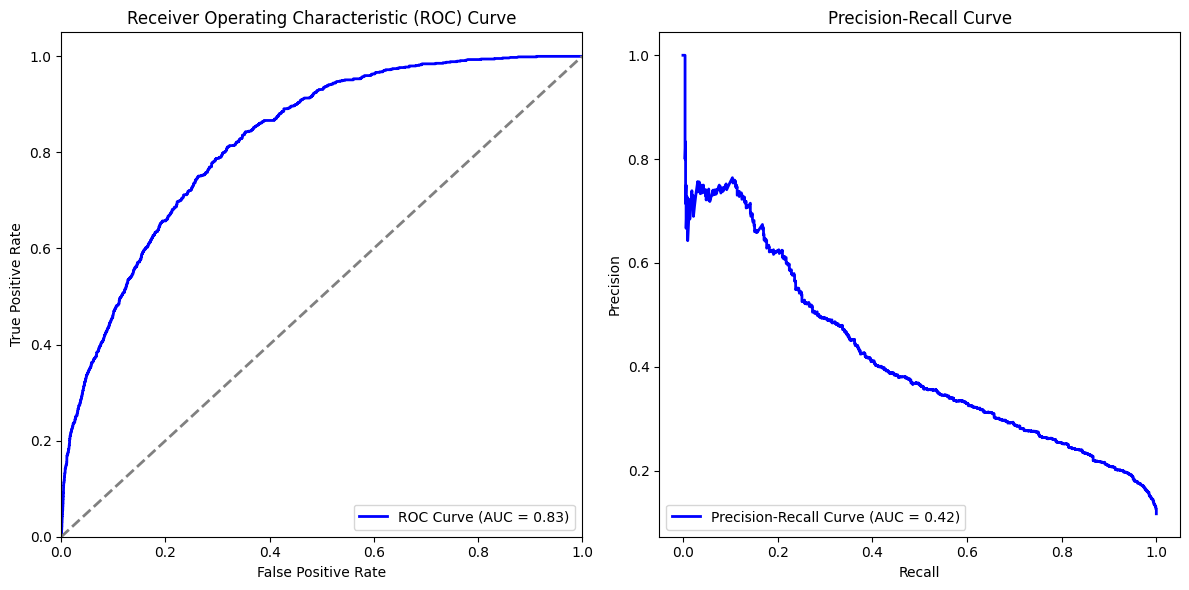

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.82      0.88      6787
           1       0.32      0.63      0.42       899

    accuracy                           0.80      7686
   macro avg       0.63      0.73      0.65      7686
weighted avg       0.87      0.80      0.82      7686



In [ ]:


# Get predicted probabilities for both classes (for the positive class, class 1)
y_pred_prob = nb_model.predict_proba(X_valid_binarized)[:, 1]

# Calculate ROC-AUC score
fpr, tpr, thresholds = roc_curve(y_valid, y_pred_prob)
roc_auc = auc(fpr, tpr)  # Calculate AUC
print(f"ROC-AUC Score: {roc_auc:.2f}")

# Plot the ROC Curve
plt.figure(figsize=(12, 6))

# ROC Curve (First plot)
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# Calculate Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_valid, y_pred_prob)

# Calculate Precision-Recall AUC
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc:.2f}")

# Precision-Recall Curve
plt.subplot(1, 2, 2)
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")

# Show both plots
plt.tight_layout()
plt.show()

# Print the classification report
y_pred = nb_model.predict(X_valid_binarized)
print("Classification Report:")
print(classification_report(y_valid, y_pred))



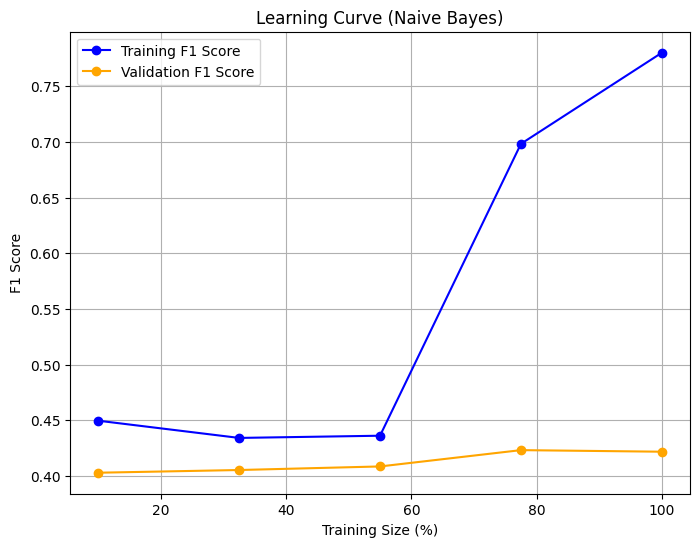

In [ ]:
# Plot learning curves
plot_learning_curve_nb(nb_model, X_train_binarized, y_train_resampled, X_valid_binarized, y_valid, "Learning Curve (Naive Bayes)")


### **Neural Network**

In [ ]:
# Define a neural network
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

    def predict(self, X_test, return_proba=False):
        dataset = TabularDataset(X_test, torch.randn(len(X_test)))
        test_loader = DataLoader(dataset, batch_size=32, shuffle=False)
        self.eval()
        thres = 0.5
        preds = []
        with torch.no_grad():
            for data in test_loader:
                inputs, _ = data
                outputs = model(inputs)
                if return_proba:
                    pred = torch.sigmoid(outputs)
                else:
                    pred = torch.sigmoid(outputs) > thres
                preds.extend(pred.numpy())
        res = [float(x[0]) for x in preds]
        return res

    def predict_proba(self, X_test):
        pred_1 = self.predict(X_test, return_proba=True)
        pred_0 = [1 - x for x in pred_1]
        return np.vstack((pred_0, pred_1)).T

In [ ]:
# Define the dataset class
class TabularDataset(Dataset):
    def __init__(self, data, targets):
        self.data =data
        self.targets = targets

    def __getitem__(self, index):
        x = torch.tensor(self.data[index], dtype=torch.float32)
        y = torch.tensor(self.targets[index], dtype=torch.float32)
        return x, y

    def __len__(self):
        return len(self.data)


# Define the training loop
def train_model(model, train_loader, criterion, optimizer, num_epochs):
    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, data in enumerate(train_loader, 0):
            inputs, labels = data
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels.reshape(-1, 1))
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1} loss: {running_loss/len(train_loader)}")
    return model

In [ ]:
# Function to compute the learning curve
def plot_learning_curve_nn(model, dataset, X_valid, y_valid, criterion, optimizer, num_epochs, batch_size=32):
    """
    Plots the learning curve for the neural network model.
    """
    train_sizes = np.linspace(0.1, 1.0, 5)  # Use 5 increments of training data
    train_f1_scores = []
    valid_f1_scores = []

    for train_size in train_sizes:
        subset_size = int(len(dataset) * train_size)
        train_subset = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        subset_loader = DataLoader(
            TabularDataset(dataset.data[:subset_size], dataset.targets[:subset_size]),
            batch_size=batch_size,
            shuffle=True,
        )

        # Reinitialize the model for each subset size
        input_size = dataset.data.shape[1]
        hidden_size = 16
        output_size = 1
        temp_model = Net(input_size, hidden_size, output_size)
        temp_optimizer = optim.Adam(temp_model.parameters(), lr=0.001)

        # Train on the subset
        train_model(temp_model, subset_loader, criterion, temp_optimizer, num_epochs)

        # Evaluate on the training subset
        y_train_pred = temp_model.predict(dataset.data[:subset_size])
        y_valid_pred = temp_model.predict(X_valid)

        train_f1_scores.append(f1_score(dataset.targets[:subset_size], y_train_pred))
        valid_f1_scores.append(f1_score(y_valid, y_valid_pred))

    # Plotting the learning curve
    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes * 100, train_f1_scores, label="Training F1 Score", marker='o', color='blue')
    plt.plot(train_sizes * 100, valid_f1_scores, label="Validation F1 Score", marker='o', color='orange')
    plt.title("Learning Curve (Neural Network)")
    plt.xlabel("Training Size (%)")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
X_train_neural_net = X_train_resampled_scaled
y = y_train_resampled

In [ ]:
# Create the dataset and dataloader
dataset = TabularDataset(X_train_neural_net, y)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Set up the neural network model, loss function, and optimizer
input_size = X_train.shape[1]
hidden_size = 16
output_size = 1
model = Net(input_size, hidden_size, output_size)
criterion = nn.BCEWithLogitsLoss() ##(pos_weight=torch.tensor([10]))  # Adjusted for class imbalance
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Train the model
num_epochs = 10
neural_network = train_model(model, train_loader, criterion, optimizer, num_epochs=num_epochs)

Epoch 1 loss: 0.35592888403655365
Epoch 2 loss: 0.29411680552105235
Epoch 3 loss: 0.2737871242020857
Epoch 4 loss: 0.26142101894908254
Epoch 5 loss: 0.2524979400723453
Epoch 6 loss: 0.24656989132797782
Epoch 7 loss: 0.24082141026248635
Epoch 8 loss: 0.23580686370449763
Epoch 9 loss: 0.23195981644818414
Epoch 10 loss: 0.2279847623142658


In [ ]:
## prediction on test set
X_valid_neural_net = scaler.transform(X_valid.values)
y_pred_neural_net = neural_network.predict(X_valid_neural_net)

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)


<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)


<Axes: ylabel='Count'>

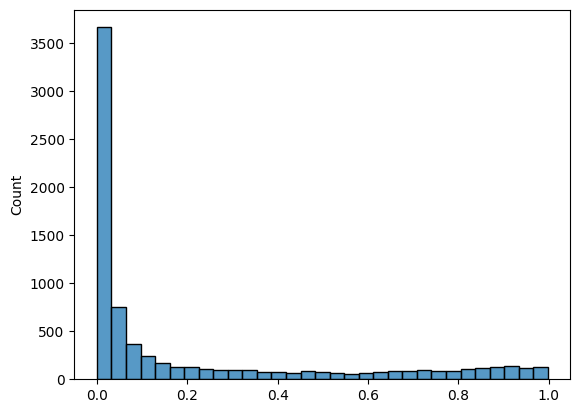

In [ ]:
## show distribution of the prediction on test set
y_pred_proba_neural_net = neural_network.predict(X_valid_neural_net, return_proba=True)
sns.histplot(y_pred_proba_neural_net)

<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)


ROC-AUC Score: 0.9078551500259034
Precision-Recall AUC: 0.53


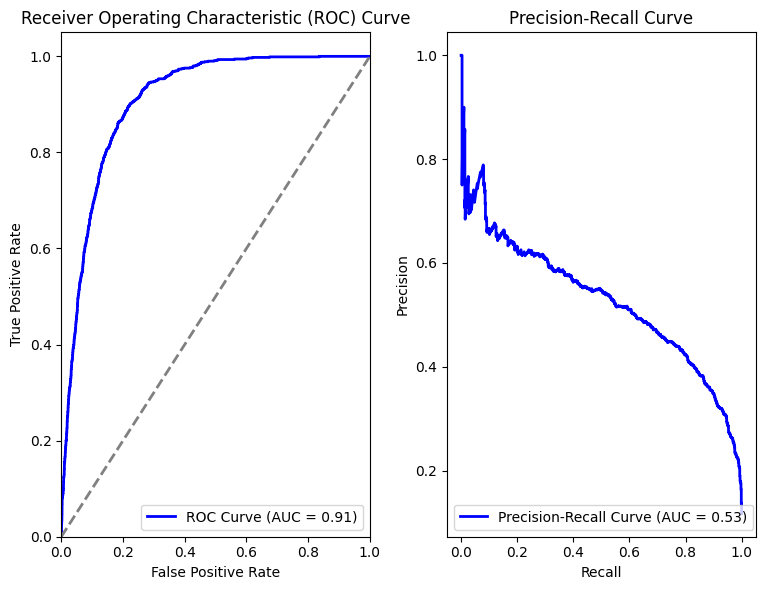

<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      6787
           1       0.45      0.75      0.56       899

    accuracy                           0.86      7686
   macro avg       0.71      0.81      0.74      7686
weighted avg       0.90      0.86      0.88      7686



In [ ]:
# Get predicted probabilities for both classes (for the positive class, class 1)
y_pred_prob = neural_network.predict_proba(X_valid_scaled)

# Calculate ROC-AUC score
fpr, tpr, thresholds = roc_curve(y_valid, y_pred_prob[:, 1])  # Use probabilities for class 1
roc_auc = auc(fpr, tpr)  # Correctly pass fpr and tpr to auc()
print(f"ROC-AUC Score: {roc_auc}")

# Plot the ROC Curve
plt.figure(figsize=(8, 6))

# ROC Curve
plt.subplot(1, 2, 1)  # Two plots, one row, two columns, first plot
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')  # Diagonal line (no skill)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# Calculate Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_valid, y_pred_prob[:, 1])

# Calculate Precision-Recall AUC
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc:.2f}")

# Precision-Recall Curve
plt.subplot(1, 2, 2)  # Second plot
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")

# Show both plots
plt.tight_layout()
plt.show()

# Print the classification report
y_pred = neural_network.predict(X_valid_scaled)  # Predicted class labels
print("Classification Report:")
print(classification_report(y_valid, y_pred))



Epoch 1 loss: 0.4139899784151246
Epoch 2 loss: 0.255538016163251
Epoch 3 loss: 0.22651131823658943
Epoch 4 loss: 0.2151554146233727
Epoch 5 loss: 0.2090705661870101
Epoch 6 loss: 0.2045718210804112
Epoch 7 loss: 0.20202313481884845
Epoch 8 loss: 0.1999325210118995
Epoch 9 loss: 0.19746048246674677
Epoch 10 loss: 0.19551776625654277


<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)


Epoch 1 loss: 0.3122049659301621
Epoch 2 loss: 0.22789367295099774
Epoch 3 loss: 0.22066779786963825
Epoch 4 loss: 0.21713124158238803
Epoch 5 loss: 0.2146952387512378
Epoch 6 loss: 0.21251480604616413
Epoch 7 loss: 0.2108042679079201
Epoch 8 loss: 0.20872088068205377
Epoch 9 loss: 0.20735991875762524
Epoch 10 loss: 0.20515250271874602


<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)


Epoch 1 loss: 0.28137219335078173
Epoch 2 loss: 0.21975203978428237
Epoch 3 loss: 0.21561886621459647
Epoch 4 loss: 0.21168198159694415
Epoch 5 loss: 0.2091258685972055
Epoch 6 loss: 0.20753456336272605
Epoch 7 loss: 0.2055802877585561
Epoch 8 loss: 0.20404408197666515
Epoch 9 loss: 0.203457792490976
Epoch 10 loss: 0.20236982924492763


<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)


Epoch 1 loss: 0.364299837712326
Epoch 2 loss: 0.3029320501272669
Epoch 3 loss: 0.2876575311610454
Epoch 4 loss: 0.2757132818037113
Epoch 5 loss: 0.2670577007129845
Epoch 6 loss: 0.2602224579385478
Epoch 7 loss: 0.25567603045260046
Epoch 8 loss: 0.2511818945011259
Epoch 9 loss: 0.24746544424005334
Epoch 10 loss: 0.2446650769207414


<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)


Epoch 1 loss: 0.3554745280196474
Epoch 2 loss: 0.2906985524152754
Epoch 3 loss: 0.2687706806261749
Epoch 4 loss: 0.2531788204969486
Epoch 5 loss: 0.24146808562256972
Epoch 6 loss: 0.2333416350594182
Epoch 7 loss: 0.22693785718813952
Epoch 8 loss: 0.2231593523668449
Epoch 9 loss: 0.21932751776702136
Epoch 10 loss: 0.21623287857474477


<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)


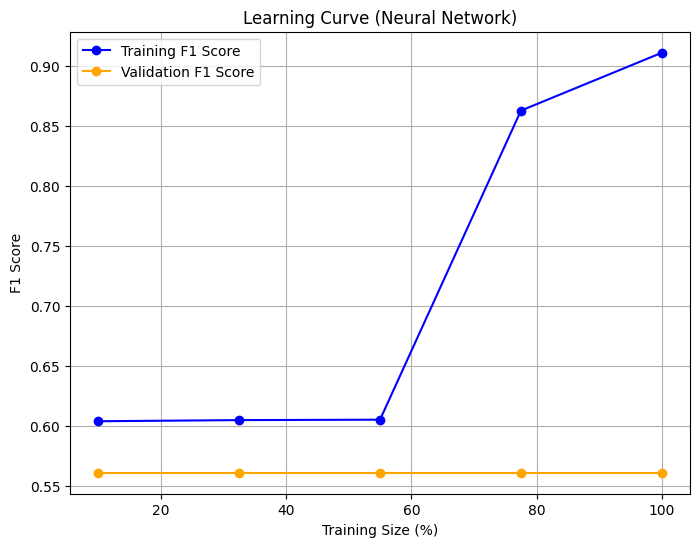

In [ ]:
# Generate learning curve
plot_learning_curve_nn(neural_network, dataset, X_valid_scaled, y_valid, criterion, optimizer, num_epochs)

## Get hidden test set

### Get hidden test set

In [ ]:
file_path = 'test.csv'
hidden_test = pd.read_csv(file_path, sep=';')
hidden_test.head(3)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,29,technician,single,secondary,no,825,no,no,cellular,25,jun,472,2,-1,0,unknown,yes
1,59,housemaid,married,secondary,no,0,no,no,telephone,5,jun,153,1,-1,0,unknown,no
2,48,technician,married,secondary,no,268,no,no,cellular,16,jul,128,1,-1,0,unknown,no


### Preprocessing and feature engineering on hidden test set

In [ ]:
# Load the hidden_testset
file_path = 'test.csv'
hidden_test = pd.read_csv(file_path, sep=';')

# Feature Engineering
# Binary flags for thresholds
hidden_test['long_campaign_contact'] = (hidden_test['campaign'] > 5).astype(int)
hidden_test['recent_contact'] = (hidden_test['pdays'] < 10).astype(int)

# Interaction terms
hidden_test['duration_campaign_interaction'] = hidden_test['duration'] * hidden_test['campaign']
hidden_test['contact_poutcome_interaction'] = hidden_test['contact'] + '_' + hidden_test['poutcome']
hidden_test['month_campaign_interaction'] = hidden_test['month'] + '_campaign_' + hidden_test['campaign'].astype(str)

# Group rare categories in 'job'
hidden_test['job_grouped'] = hidden_test['job'].replace(
    hidden_test['job'].value_counts()[hidden_test['job'].value_counts() < 500].index, 'Other'
)
hidden_test['age_group'] = pd.cut(hidden_test['age'], bins=[0, 25, 45, 65, 100], labels=['Youth', 'Adult', 'Middle-Aged', 'Senior'])

# Step 2: Select relevant features
numerical_features = ['duration', 'balance', 'pdays']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
engineered_features = ['duration_campaign_interaction', 'long_campaign_contact', 'recent_contact', 'age_group']

# Step 3: One-hot encode categorical features
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_cat = encoder.fit_transform(hidden_test[categorical_features + ['age_group']])
encoded_feature_names = encoder.get_feature_names_out(categorical_features + ['age_group'])

# Step 4: Combine numerical, encoded, and engineered features
X_encoded_df = pd.DataFrame(X_cat, columns=encoded_feature_names, index=hidden_test.index)
hidden_test = pd.concat([X_encoded_df, hidden_test[numerical_features + engineered_features]], axis=1)


# Verify the newly created features
hidden_test.drop(['age_group'], axis=1, inplace=True)
print(len(hidden_test.columns))
hidden_test_X = hidden_test
hidden_test_y =  (pd.read_csv(file_path, sep=';')['y'] == 'yes').astype(int)


44


### Sanity check: make sure the columns are the same for hidden test and training set

In [ ]:
assert set(sorted(X_final.columns)) - set(sorted(hidden_test_X.columns)) == set()
assert set(sorted(hidden_test_X.columns))  - set(sorted(X_final.columns))  == set()

## Evaluation

### Metrics report

In [ ]:
def f1_score_weighted(y_true, y_pred):
    return f1_score(y_true, y_pred, average="weighted")

def get_evaluation(X_dict, y_ground_truth):

    # Evaluate models
    models = {
        'Logistic Regression': best_model_logistic,
        'Naive Bayes': nb_model,
        'Neural Network': neural_network
    }

    metrics = {
        'Accuracy': accuracy_score,
        'Precision': precision_score,
        'Recall': recall_score,
        'F1-Score': f1_score_weighted
    }


    results = []
    for model_name, model in models.items():
        row = [model_name]
        for metric_name, metric_func in metrics.items():
            y_pred = model.predict(X_dict[model_name])
            score = metric_func(y_ground_truth.values.reshape(-1), y_pred)
            row.append(score)
        results.append(row)

    # store results as a Data Frame
    columns = ['Model'] + list(metrics.keys())
    performance_df = pd.DataFrame(results, columns=columns)

    return performance_df

#### Train

In [ ]:
X_train_dict ={
    'Logistic Regression': X_train_resampled_scaled,
    'Naive Bayes': X_train_binarized,
    'Neural Network': X_train_neural_net
}

report_training_set = get_evaluation(X_train_dict, y_train_resampled)
report_training_set

<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)
<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)
<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)
<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.853164,0.846802,0.862337,0.853152
1,Naive Bayes,0.787188,0.807171,0.754660,0.786962
2,Neural Network,0.909195,0.891706,0.931518,0.909149


#### Validation

In [ ]:
X_valid_dict = {
    'Logistic Regression': X_valid_scaled,
    'Naive Bayes': X_valid_binarized,
    'Neural Network': X_valid_neural_net
}
y_ground_truth = y_valid

report_test_set = get_evaluation(X_valid_dict, y_ground_truth)
report_test_set

<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)
<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)
<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)
<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.836716,0.402519,0.817575,0.858505
1,Naive Bayes,0.796643,0.315965,0.634038,0.823423
2,Neural Network,0.862998,0.448667,0.748610,0.876985


#### Hidden Test

In [ ]:
## scale the hidden test set
X_hidden_test_scaled_logistic = scaler.transform(hidden_test_X)

X_hidden_test_scaled = scaler.transform(hidden_test_X)
X_hidden_test_binarized = binarizer.transform(X_hidden_test_scaled)
X_hidden_test_binarized = X_hidden_test_binarized.astype(int)

X_hidden_test_neural_net = scaler.transform(hidden_test_X)

X_hidden_test_dict = {
    'Logistic Regression': X_hidden_test_scaled_logistic,
    'Naive Bayes': X_hidden_test_binarized,
    'Neural Network': X_hidden_test_neural_net
}
y_ground_truth = hidden_test_y

report_test_set = get_evaluation(X_hidden_test_dict, y_ground_truth)
report_test_set

<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)
<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)
<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)
<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.828222,0.387409,0.807062,0.851762
1,Naive Bayes,0.793276,0.312153,0.638083,0.821054
2,Neural Network,0.861103,0.445261,0.764187,0.875959


### Confusion Matrix

In [ ]:
def plot_confusion_matrix(model_name, cm):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", xticklabels=["Class 0", "Class 1"], yticklabels=["Class 0", "Class 1"])
    plt.xlabel("Predicted labels")
    plt.ylabel("Actual labels")
    plt.title("Confusion Matrix for {}".format(model_name))
    plt.show()

#### Validation

<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)


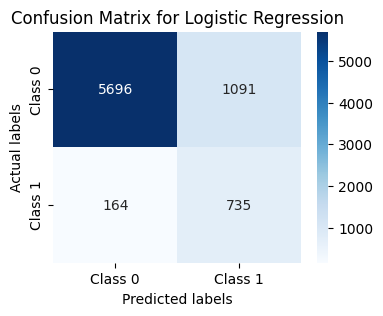

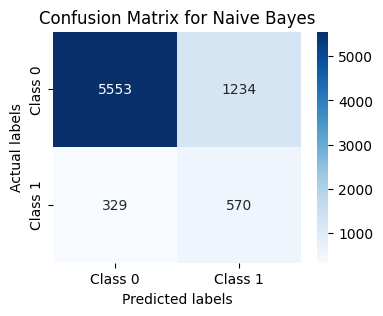

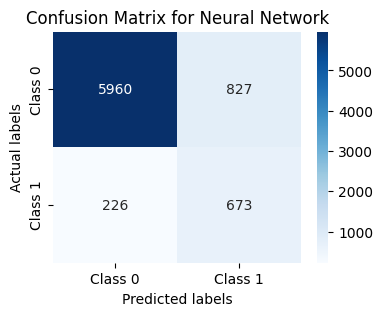

In [ ]:
y_valid_pred_logistic = best_model_logistic.predict(X_valid_scaled)
y_valid_pred_nb = nb_model.predict(X_valid_binarized)
y_valid_pred_neural_net = neural_network.predict(X_valid_neural_net)

model_preds = {
    'Logistic Regression': y_valid_pred_logistic,
    'Naive Bayes': y_valid_pred_nb,
    'Neural Network': y_valid_pred_neural_net
}
for model_name, y_pred in model_preds.items():
    cm = confusion_matrix(y_valid, y_pred)
    plot_confusion_matrix(model_name, cm)


#### Hidden Test

<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)


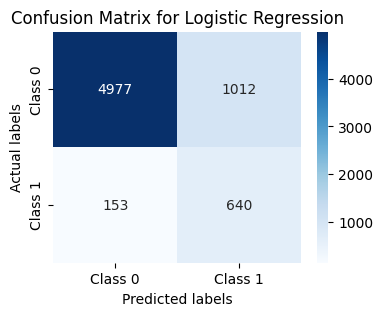

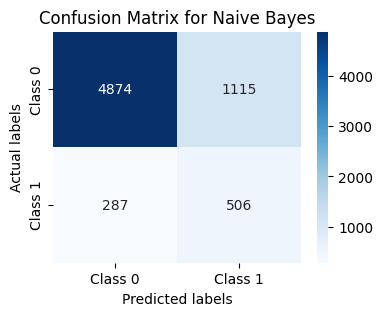

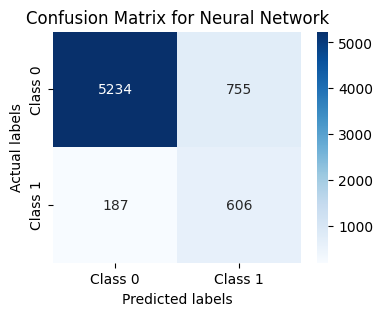

In [ ]:
y_hidden_test_pred_logistic = best_model_logistic.predict(X_hidden_test_scaled_logistic)
y_hidden_test_pred_nb = nb_model.predict(X_hidden_test_binarized)
y_hidden_test_pred_neural_net = neural_network.predict(X_hidden_test_neural_net)

model_preds = {
    'Logistic Regression': y_hidden_test_pred_logistic,
    'Naive Bayes': y_hidden_test_pred_nb,
    'Neural Network': y_hidden_test_pred_neural_net
}
for model_name, y_pred in model_preds.items():
    cm = confusion_matrix(hidden_test_y, y_pred)
    plot_confusion_matrix(model_name, cm)


### ROC AUC curve

#### Validation

<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)


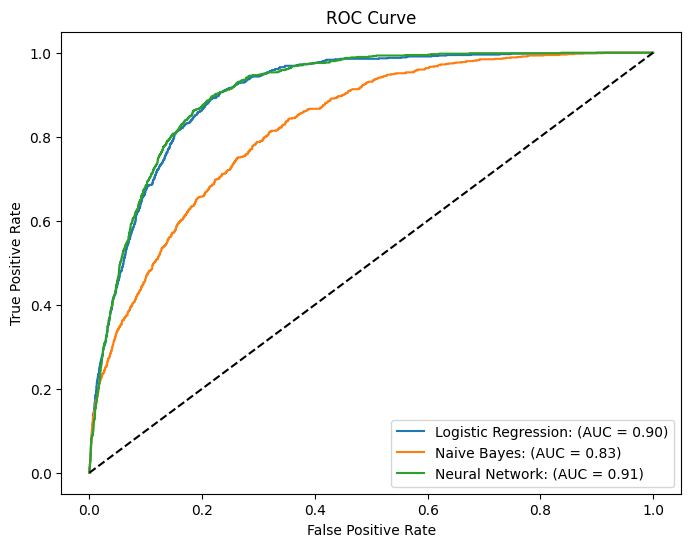

In [ ]:
y_pred_logistic_prob = best_model_logistic.predict_proba(X_valid_scaled)[:, 1]
y_pred_nb_prob = nb_model.predict_proba(X_valid_binarized)[:, 1]
y_pred_neural_net_prob = neural_network.predict_proba(X_valid_neural_net)[:, 1]

model_proba_reds = {
    'Logistic Regression': y_pred_logistic_prob,
    'Naive Bayes': y_pred_nb_prob,
    'Neural Network': y_pred_neural_net_prob
}

plt.figure(figsize=(8, 6))
for model_name, y_pred in model_proba_reds.items():
    fpr, tpr, _ = roc_curve(y_valid, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name}: (AUC = {roc_auc:.2f})')


plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

#### Hidden Test

<ipython-input-50-66636e410a11>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(self.targets[index], dtype=torch.float32)


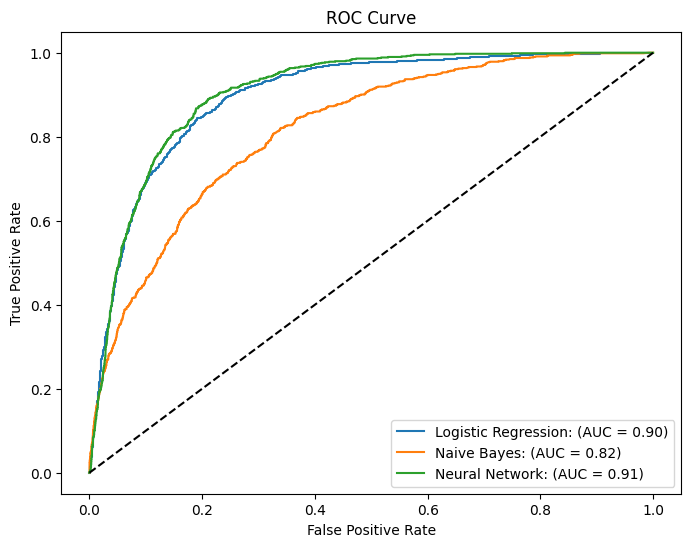

In [ ]:
y_pred_logistic_prob = best_model_logistic.predict_proba(X_hidden_test_scaled_logistic)[:, 1]
y_pred_nb_prob = nb_model.predict_proba(X_hidden_test_binarized)[:, 1]
y_pred_neural_net_prob = neural_network.predict_proba(X_hidden_test_neural_net)[:, 1]

model_proba_reds = {
    'Logistic Regression': y_pred_logistic_prob,
    'Naive Bayes': y_pred_nb_prob,
    'Neural Network': y_pred_neural_net_prob
}

plt.figure(figsize=(8, 6))
for model_name, y_pred in model_proba_reds.items():
    fpr, tpr, _ = roc_curve(hidden_test_y, y_pred)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name}: (AUC = {roc_auc:.2f})')


plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()